# Day 34 — Feature Importance & AdaBoost
- Understand feature importance in tree ensembles.
- Interpret feature importance carefully.
- Understand the boosting idea.
- Understand AdaBoost and sequential error correction.
- Understand the learning rate.
- Compare Random Forest and AdaBoost.


## 1. Feature Importance

Feature importance estimates how useful each feature was for making predictions.

For tree ensembles, scikit-learn exposes impurity-based feature importance through:

```python
model.feature_importances_
```

### Important caveat
Feature importance is **not causality**. A highly important feature is useful to the model, but this does not mean it causes the target.

Impurity-based importance can also be biased in some situations, so permutation importance can be a useful complementary method.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
feature_names = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

forest.fit(X_train, y_train)

print("Test accuracy:", forest.score(X_test, y_test))


Test accuracy: 0.9


petal length (cm)    0.453793
petal width (cm)     0.412449
sepal length (cm)    0.115873
sepal width (cm)     0.017885
dtype: float64


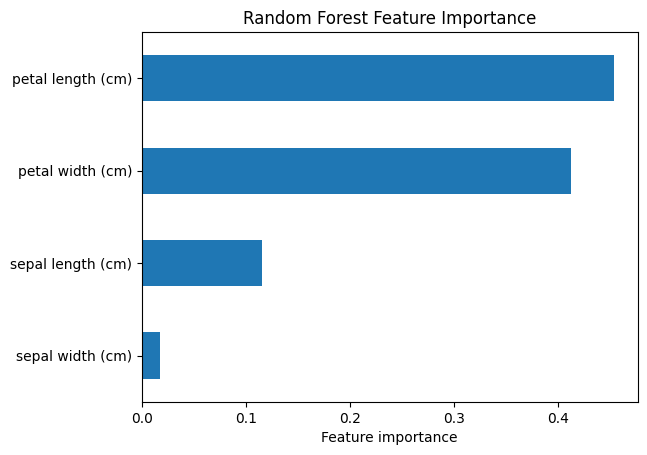

In [2]:
importance = pd.Series(
    forest.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance)

importance.sort_values().plot.barh()
plt.xlabel("Feature importance")
plt.title("Random Forest Feature Importance")
plt.show()


## 2. What Is Boosting?

**Boosting** combines several weak learners into a stronger ensemble.

Unlike bagging, the learners are trained **sequentially**.

Conceptually:

```text
Weak Learner 1
      ↓
Find mistakes
      ↓
Weak Learner 2 focuses more on difficult examples
      ↓
Find remaining mistakes
      ↓
Weak Learner 3
      ↓
...
      ↓
Strong ensemble
```

The key idea is **sequential correction**.


## 3. AdaBoost

**AdaBoost = Adaptive Boosting**

Basic process:

1. Start with equal weights for training instances.
2. Train a weak learner.
3. Identify incorrectly classified examples.
4. Increase the importance/weight of difficult examples.
5. Train another weak learner.
6. Repeat.
7. Combine learners using weighted voting.

A common weak learner is a **decision stump** — a decision tree with `max_depth=1`.


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)

print("AdaBoost accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))


AdaBoost accuracy: 0.9666666666666667

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 4. Decision Stump

A decision stump is a tree with only one split.

```text
             Feature < threshold?
                /          \
              Yes           No
               ↓             ↓
            Class A       Class B
```

In AdaBoost, many simple learners can be combined to create a powerful model.


In [4]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)

print("Decision stump accuracy:", stump.score(X_test, y_test))
print("Number of tree nodes:", stump.tree_.node_count)


Decision stump accuracy: 0.6666666666666666
Number of tree nodes: 3


## 5. Learning Rate

`learning_rate` controls how strongly each new weak learner contributes to the ensemble.

Typical trade-off:

```text
Higher learning rate
    → each learner has more influence
    → fewer learners may be needed

Lower learning rate
    → each learner has less influence
    → usually more learners are needed
```

Let's experiment with different learning rates.


In [5]:
learning_rates = [0.05, 0.1, 0.5, 1.0]
results = []

for lr in learning_rates:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=200,
        learning_rate=lr,
        random_state=42
    )
    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    results.append({
        "learning_rate": lr,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })

results_df = pd.DataFrame(results)
results_df


,learning_rate,train_accuracy,test_accuracy
0,0.05,0.983333,0.966667
1,0.10,0.983333,0.933333
2,0.50,1.000000,0.933333
3,1.00,1.000000,0.933333


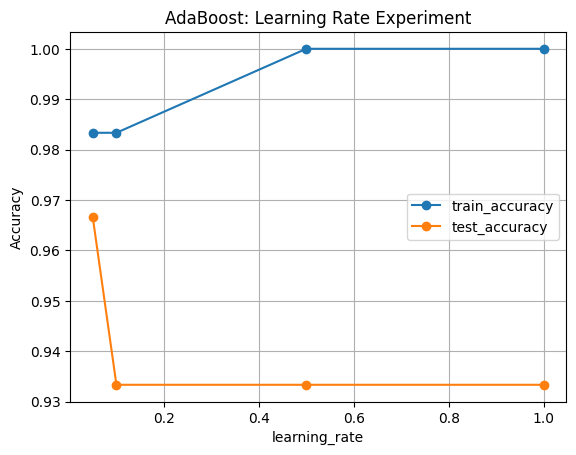

In [6]:
results_df.plot(
    x="learning_rate",
    y=["train_accuracy", "test_accuracy"],
    marker="o"
)

plt.ylabel("Accuracy")
plt.title("AdaBoost: Learning Rate Experiment")
plt.grid(True)
plt.show()


## 6. Random Forest vs AdaBoost

| Random Forest | AdaBoost |
|---|---|
| Bagging | Boosting |
| Trees trained independently | Learners trained sequentially |
| Uses randomness | Focuses on difficult examples |
| Easy to parallelize | Sequential training |
| Strong variance reduction | Can reduce bias and variance |

### Memory trick

**Random Forest:** many trees + randomness + independent training.

**AdaBoost:** many weak learners + sequential correction + focus on mistakes.


In [7]:
# Compare Random Forest and AdaBoost on the same test set

rf_accuracy = forest.score(X_test, y_test)
ada_accuracy = ada.score(X_test, y_test)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost"],
    "Test Accuracy": [rf_accuracy, ada_accuracy]
})

comparison


,Model,Test Accuracy
0,Random Forest,0.900000
1,AdaBoost,0.966667


## 7. Optional: Permutation Importance

Impurity-based feature importance is convenient, but permutation importance provides another interpretation.

The idea is simple:

> Shuffle one feature at a time and measure how much the model's performance decreases.

A large decrease suggests that the model relied heavily on that feature.


petal length (cm)    0.335000
petal width (cm)     0.080000
sepal width (cm)    -0.036667
sepal length (cm)   -0.058333
dtype: float64


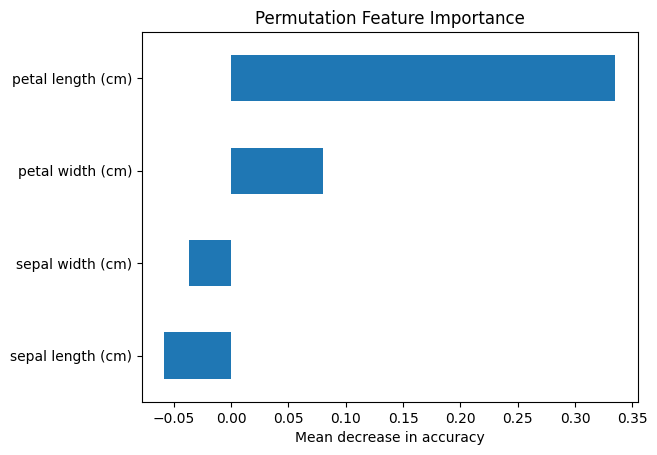

In [8]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    forest,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=feature_names
).sort_values(ascending=False)

print(perm_importance)

perm_importance.sort_values().plot.barh()
plt.xlabel("Mean decrease in accuracy")
plt.title("Permutation Feature Importance")
plt.show()


# Day 34 Summary

### Must remember

- **Feature importance** → how useful features were to the model.
- **Feature importance ≠ causality.**
- **Boosting** → sequentially combine weak learners.
- **AdaBoost** → increase focus on examples previous learners got wrong.
- **Decision stump** → shallow tree, commonly `max_depth=1`.
- **Learning rate** → controls each learner's contribution.
- Lower learning rate often requires more estimators.
- Random Forest uses **bagging + randomness**.
- AdaBoost uses **boosting + sequential correction**.
